In [1]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
def results_to_df(results_list, dataset, sampling_method):
    res = []
    for config in results_list:
        #print(config.keys())
        if sampling_method.endswith("_dp"):
            e = config["e"]
        else:
            e = np.inf
        b = config["b"]
        test_bacc = config["test_bacc"]
        e = config["e"]
        res.append((dataset, sampling_method, e, b, test_bacc))
    
    return pd.DataFrame.from_records(res, columns=["dataset", "sampling", "e", "b", "test_bacc"])

In [31]:
"""DATASET = "ml1m"
PATH = DATASET + "/"
with open(PATH + "attacker.random_dp", "rb") as f:
    results = pkl.load(f)
    random_dp_df = results_to_df(results, DATASET, "random_dp")
with open(PATH + "attacker.ister_dp", "rb") as f:
    results = pkl.load(f)
    ister_dp_df = results_to_df(results, DATASET, "ister_dp")
ml1m_results_df = pd.concat([random_dp_df, ister_dp_df]).reset_index(drop=True)"""

DATASET = "bx"
PATH = DATASET + "/"
with open(PATH + "attacker.random_dp", "rb") as f:
    results = pkl.load(f)
    random_dp_df = results_to_df(results, DATASET, "random_dp")
with open(PATH + "attacker.ister_dp", "rb") as f:
    results = pkl.load(f)
    ister_dp_df = results_to_df(results, DATASET, "ister_dp")
bx_results_df = pd.concat([random_dp_df, ister_dp_df]).reset_index(drop=True)

#results_df = pd.concat([ml1m_results_df, bx_results_df])
#results_df

In [29]:
random01 = ml1m_results_df[(ml1m_results_df["sampling"] == "random_dp") & (ml1m_results_df["e"] == 0.1)]
random3 = ml1m_results_df[(ml1m_results_df["sampling"] == "random_dp") & (ml1m_results_df["e"] == 3)]
plt.plot(random01["b"], random01["test_bacc"], label=r"Rand. $\epsilon=0.1$", c="C1")
plt.plot(random3["b"], random3["test_bacc"], label=r"Rand. $\epsilon=3$", c="C1", linestyle="dashed")

ister01 = ml1m_results_df[(ml1m_results_df["sampling"] == "ister_dp") & (ml1m_results_df["e"] == 0.1)]
ister3 = ml1m_results_df[(ml1m_results_df["sampling"] == "ister_dp") & (ml1m_results_df["e"] == 3)]
plt.plot(ister01["b"], ister01["test_bacc"], label=r"Stereo $\epsilon=0.1$", c="C1")
plt.plot(ister3["b"], ister3["test_bacc"], label=r"Stereo $\epsilon=3$", c="C2", linestyle="dashed")

plt.gca().invert_xaxis()
#plt.title("BAcc.")
plt.legend(ncol=2)
plt.ylabel("BAcc.")
plt.xlabel("Data Budget")
plt.ylim([0.5, 0.8])
plt.show()

NameError: name 'ml1m_results_df' is not defined

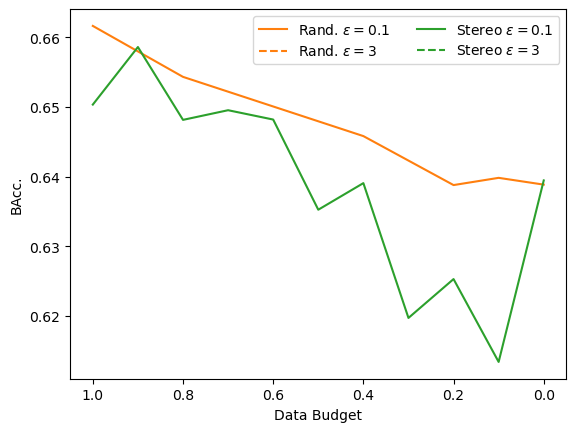

In [32]:
random01 = bx_results_df[(bx_results_df["sampling"] == "random_dp") & (bx_results_df["e"] == 0.1)]
random3 = bx_results_df[(bx_results_df["sampling"] == "random_dp") & (bx_results_df["e"] == 3)]
plt.plot(random01["b"], random01["test_bacc"], label=r"Rand. $\epsilon=0.1$", c="C1")
plt.plot(random3["b"], random3["test_bacc"], label=r"Rand. $\epsilon=3$", c="C1", linestyle="dashed")

ister01 = bx_results_df[(bx_results_df["sampling"] == "ister_dp") & (bx_results_df["e"] == 0.1)]
ister3 = bx_results_df[(bx_results_df["sampling"] == "ister_dp") & (bx_results_df["e"] == 3)]
plt.plot(ister01["b"], ister01["test_bacc"], label=r"Stereo $\epsilon=0.1$", c="C2")
plt.plot(ister3["b"], ister3["test_bacc"], label=r"Stereo $\epsilon=3$", c="C2", linestyle="dashed")

plt.gca().invert_xaxis()
#plt.title("BAcc.")
plt.legend(ncol=2)
plt.ylabel("BAcc.")
plt.xlabel("Data Budget")
#plt.ylim([0.54, 0.68])
plt.show()